# Thicket Nsight Compute Reader: Thicket Tutorial

Nsight Compute (NCU) is a performance profiler for NVIDIA GPUs. NCU report files do not have a calltree, but with the NVTX Caliper service we can forward Caliper annotations to NCU. By profiling the same executable with a calltree profiler like Caliper, we can map the NCU data to the calltree profile and create a Thicket object. 

In Section 6, we reproduce some of the analysis and visualizations from the paper:

Olga Pearce, Jason Burmark, Rich Hornung, Befikir Bogale, Ian Lumsden, Michael McKinsey, Dewi Yokelson, David Boehme, Stephanie Brink, Michela Taufer, and Tom Scogland. “RAJA Performance Suite: Performance Portability Analysis with Caliper and Thicket”. SC-W 2024: Workshops of ACM/IEEE International Conference for High Performance Computing, Networking, Storage, and Analysis. Performance, Portability & Productivity in HPC. 2024.

***

## 1. Import Necessary Packages

The Thicket NCU reader requires an existing install of Nsight Compute, and the `extras/python` directory in the Nsight Compute installation directory must be added to the `PYTHONPATH`. We use `sys.path.append` to add the path to the `PYTHONPATH` in this notebook. If you are not on a Livermore Computing system, you must change this path to match your install of Nsight Compute.

**VERSION NOTICE: This functionality is tested with nsight-compute version 2023.2.2. Your mileage may vary if using a different version.**

In [1]:
import os
import sys

sys.path.append("/usr/tce/packages/nsight-compute/nsight-compute-2023.2.2/extras/python")

from IPython.display import display
from IPython.display import HTML

import thicket as tt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

display(HTML("<style>.container { width:80% !important; }</style>"))

In [2]:
pd.set_option("display.max_columns", 500)

In [3]:
# tt.Thicket.from_caliperreader("/usr/workspace/thicket/grace-rajaperf-cascadelake-a100/results_GCC-12.3.0-NVHPC-23.7-CUDA-12.2.0/RAJA_CUDA/block_256/16777216/0.5-rf/cuda_profile.cali").metadata

In [4]:
ncu_report_mapping = {}

In [5]:
for dirpath, dirnames, filenames in os.walk("../data/ncu/gr-gh200-roofline"):
    if "cuda_profile.cali" in filenames and "report.ncu-rep" in filenames:
        print(f"Current Directory: {dirpath}")
        ncu_report_mapping[dirpath + "/report.ncu-rep"] = dirpath + "/cuda_profile.cali"
        break

Current Directory: ../data/ncu/gr-gh200-roofline


In [6]:
tk_roofline = tt.Thicket.from_caliperreader(list(ncu_report_mapping.values()))
tk_roofline.dataframe.head(10)

(1/2) Reading Files: 100%|██████████| 1/1 [00:00<00:00,  4.97it/s]
0it [00:00, ?it/s]


,,nid,time,time (gpu),name
node,profile,,,,
"{'name': 'RAJAPerf', 'type': 'function'}",3273507227914,37.0,0.001441,NaN,RAJAPerf
"{'name': 'Algorithm', 'type': 'function'}",3273507227914,207.0,0.000060,NaN,Algorithm
"{'name': 'Algorithm_MEMCPY', 'type': 'function'}",3273507227914,211.0,0.000059,NaN,Algorithm_MEMCPY
"{'name': 'cudaDeviceSynchronize', 'type': 'function'}",3273507227914,213.0,0.000137,NaN,cudaDeviceSynchronize
"{'name': 'cudaLaunchKernel', 'type': 'function'}",3273507227914,212.0,0.000422,NaN,cudaLaunchKernel
"{'name': 'void RAJA::policy::cuda::impl::forall_cuda_kernel<RAJA::policy::cuda::cuda_exec_explicit<RAJA::iteration_mapping::Direct, RAJA::cuda::IndexGlobal<(RAJA::named_dim)0, 256, 0>, RAJA::cuda::MaxOccupancyConcretizer, 1ul, true>, 1ul, RAJA::Iterators::numeric_iterator<long, long, long*>, rajaperf::algorithm::MEMCPY::runCudaVariantBlock<256ul>(rajaperf::VariantID)::{lambda(long)#2}, long, RAJA::iteration_mapping::Direct, RAJA::cuda::IndexGlobal<(RAJA::named_dim)0, 256, 0>, 256ul>(rajaperf::algorithm::MEMCPY::runCudaVariantBlock<256ul>(rajaperf::VariantID)::{lambda(long)#2}, RAJA::Iterators::numeric_iterator<long, long, long*>, long)', 'type': 'kernel'}",3273507227914,259.0,NaN,0.000158,void RAJA::policy::cuda::impl::forall_cuda_ker...
"{'name': 'Algorithm_MEMSET', 'type': 'function'}",3273507227914,208.0,0.000053,NaN,Algorithm_MEMSET
"{'name': 'cudaDeviceSynchronize', 'type': 'function'}",3273507227914,210.0,0.000063,NaN,cudaDeviceSynchronize
"{'name': 'cudaLaunchKernel', 'type': 'function'}",3273507227914,209.0,0.000414,NaN,cudaLaunchKernel


In [7]:
tk_roofline.metadata["cmdline"].iloc[0]

['./raja-perf.exe',
 '--size',
 '33554432',
 '--variants',
 'RAJA_CUDA',
 '--outdir',
 '/home/users/dewiy/rajafiles/outfiles/roofline/gr-gh200/raja_cuda/32M/block_256/1/',
 '--checkrun',
 '1',
 '--tunings',
 'block_256']

In [8]:
print(tk_roofline.tree())

  _____ _     _      _        _   
 |_   _| |__ (_) ___| | _____| |_ 
   | | | '_ \| |/ __| |/ / _ \ __|
   | | | | | | | (__|   <  __/ |_ 
   |_| |_| |_|_|\___|_|\_\___|\__|  v2024.2.1

0.001 RAJAPerf
├─ 0.000 Algorithm
│  ├─ 0.000 Algorithm_MEMCPY
│  │  ├─ 0.000 cudaDeviceSynchronize
│  │  └─ 0.000 cudaLaunchKernel
│  │     └─ nan void RAJA::policy:...ong, long*>, long)
│  └─ 0.000 Algorithm_MEMSET
│     ├─ 0.000 cudaDeviceSynchronize
│     └─ 0.000 cudaLaunchKernel
│        └─ nan void RAJA::policy:...ong, long*>, long)
├─ 0.000 Apps
│  ├─ 0.000 Apps_DEL_DOT_VEC_2D
│  │  ├─ 0.000 cudaDeviceSynchronize
│  │  └─ 0.001 cudaLaunchKernel
│  │     └─ nan void RAJA::policy:...)#2}, long*, long)
│  ├─ 0.000 Apps_EDGE3D
│  │  ├─ 0.263 cudaDeviceSynchronize
│  │  └─ 0.015 cudaLaunchKernel
│  │     └─ nan void RAJA::policy:...ong, long*>, long)
│  ├─ 0.000 Apps_ENERGY
│  │  ├─ 0.002 cudaDeviceSynchronize
│  │  └─ 0.001 cudaLaunchKernel
│  │     ├─ nan void RAJA::policy:...ong, long*>, long)
│ 

In [9]:
# Add NCU to thicket
# ncu_metrics = [
#     "gpu__time_duration.sum",
#     "sm__throughput.avg.pct_of_peak_sustained_elapsed",
#     "smsp__maximum_warps_avg_per_active_cycle",
# ]
# Add in metrics
tk_roofline.add_ncu(
    ncu_report_mapping=ncu_report_mapping, 
    #chosen_metrics=ncu_metrics,
    debug=False,
)
tk_roofline.dataframe.head(20)

Processing action 6341/6342: 100%|██████████| 6342/6342 [01:10<00:00, 89.38it/s] 


,,nid,time,time (gpu),name,c2clink__enabled_mask,c2clink__present,device__attribute_architecture,device__attribute_async_engine_count,device__attribute_can_flush_remote_writes,device__attribute_can_map_host_memory,device__attribute_can_tex2d_gather,device__attribute_can_use_64_bit_stream_mem_ops,device__attribute_can_use_64_bit_stream_mem_ops_v1,device__attribute_can_use_host_pointer_for_registered_mem,device__attribute_can_use_stream_mem_ops_v1,device__attribute_can_use_stream_wait_value_nor,device__attribute_can_use_stream_wait_value_nor_v1,device__attribute_chip,device__attribute_clock_rate,device__attribute_cluster_launch,device__attribute_compute_capability_major,device__attribute_compute_capability_minor,device__attribute_compute_mode,device__attribute_compute_preemption_supported,device__attribute_concurrent_kernels,device__attribute_concurrent_managed_access,device__attribute_confidential_computing_mode,device__attribute_cooperative_launch,device__attribute_cooperative_multi_device_launch,device__attribute_deferred_mapping_cuda_array_supported,device__attribute_device_index,device__attribute_direct_managed_mem_access_from_host,device__attribute_display_name,device__attribute_dma_buf_supported,device__attribute_ecc_enabled,device__attribute_fb_bus_width,device__attribute_fbp_count,device__attribute_generic_compression_supported,device__attribute_global_l1_cache_supported,device__attribute_global_memory_bus_width,device__attribute_gpu_direct_rdma_flush_writes_options,device__attribute_gpu_direct_rdma_supported,device__attribute_gpu_direct_rdma_with_cuda_vmm_supported,device__attribute_gpu_direct_rdma_writes_ordering,device__attribute_gpu_overlap,device__attribute_gpu_pci_device_id,device__attribute_gpu_pci_ext_device_id,device__attribute_gpu_pci_ext_downstream_link_rate,device__attribute_gpu_pci_ext_downstream_link_width,device__attribute_gpu_pci_ext_gen,device__attribute_gpu_pci_ext_gpu_gen,device__attribute_gpu_pci_ext_gpu_link_rate,device__attribute_gpu_pci_ext_gpu_link_width,device__attribute_gpu_pci_revision_id,device__attribute_gpu_pci_sub_system_id,device__attribute_handle_type_posix_file_descriptor_supported,device__attribute_handle_type_win32_handle_supported,device__attribute_handle_type_win32_kmt_handle_supported,device__attribute_host_native_atomic_supported,device__attribute_host_numa_id,device__attribute_host_register_supported,device__attribute_implementation,device__attribute_integrated,device__attribute_ipc_event_supported,device__attribute_kernel_exec_timeout,device__attribute_l2_cache_size,device__attribute_l2s_count,device__attribute_limits_max_cta_per_sm,device__attribute_local_l1_cache_supported,device__attribute_managed_memory,device__attribute_max_access_policy_window_size,device__attribute_max_block_dim_x,device__attribute_max_block_dim_y,device__attribute_max_block_dim_z,device__attribute_max_blocks_per_multiprocessor,device__attribute_max_gpu_frequency_khz,device__attribute_max_grid_dim_x,device__attribute_max_grid_dim_y,device__attribute_max_grid_dim_z,device__attribute_max_ipc_per_multiprocessor,device__attribute_max_ipc_per_scheduler,device__attribute_max_mem_frequency_khz,device__attribute_max_persisting_l2_cache_size,device__attribute_max_pitch,device__attribute_max_registers_per_block,device__attribute_max_registers_per_multiprocessor,device__attribute_max_registers_per_thread,device__attribute_max_shared_memory_per_block,device__attribute_max_shared_memory_per_block_optin,device__attribute_max_shared_memory_per_multiprocessor,device__attribute_max_threads_per_block,device__attribute_max_threads_per_multiprocessor,device__attribute_max_warps_per_multiprocessor,device__attribute_max_warps_per_scheduler,device__attribute_maximum_surface1d_layered_layers,device__attribute_maximum_surface1d_layered_width,device__attribute_maximum_surface1d_width,device__attribute_maximum_surface2d_height,device__attribute_maximum_surface2d_layered_height,device__attribute_maximum_surface2d_layered_layers,devi

In [10]:
Memory_bound = ['Algorithm_MEMCPY',
 'Algorithm_MEMSET',
 'Apps_ENERGY',
 'Apps_MATVEC_3D_STENCIL',
 'Apps_PRESSURE',
 'Apps_ZONAL_ACCUMULATION_3D',
 'Basic_ARRAY_OF_PTRS',
 'Basic_COPY8',
 'Basic_DAXPY',
 'Basic_IF_QUAD',
 'Basic_INIT3',
 'Basic_MULADDSUB',
 'Lcals_DIFF_PREDICT',
 'Lcals_EOS',
 'Lcals_FIRST_DIFF',
 'Lcals_FIRST_SUM',
 'Lcals_GEN_LIN_RECUR',
 'Lcals_HYDRO_1D',
 'Lcals_HYDRO_2D',
 'Lcals_INT_PREDICT',
 'Lcals_TRIDIAG_ELIM',
 'Polybench_ADI',
 'Polybench_FDTD_2D',
 'Polybench_JACOBI_1D',
 'Polybench_JACOBI_2D',
 'Stream_ADD',
 'Stream_COPY',
 'Stream_MUL',
 'Stream_TRIAD']

retiring_bound = ['Apps_CONVECTION3DPA',
 'Apps_DEL_DOT_VEC_2D',
 'Apps_DIFFUSION3DPA',
 'Apps_FIR',
 'Apps_LTIMES',
 'Apps_LTIMES_NOVIEW',
 'Apps_MASS3DEA',
 'Apps_MASS3DPA',
 'Apps_VOL3D',
 'Basic_INIT_VIEW1D',
 'Basic_INIT_VIEW1D_OFFSET',
 'Basic_MAT_MAT_SHARED',
 'Basic_NESTED_INIT',
 'Lcals_PLANCKIAN',
 'Polybench_ATAX',
 'Polybench_HEAT_3D',
 'Polybench_MVT']

def kernel_query(kernel_list):
    return tt.query.Query().match(
        ".",
        lambda row: row["name"].apply(
            lambda n: n in kernel_list
        ).all()
    ).rel("*")

In [11]:
# Options (can be more than one): ["Algorithm", "Apps", "Basic", "Comm", "Lcals", "Polybench", "Stream"]
kernel_types = ["Algorithm", "Apps", "Basic", 
                #"Comm", 
                "Lcals", "Polybench", "Stream"]

raja_kernel_query = (
    tt.query.Query()
    .match (
        ".",
        lambda row: row["name"].apply(
            lambda x: any([x.startswith(c + "_") for c in kernel_types])
        ).all()
    )
    .rel("*")
)

pruned_th = tk_roofline.query(raja_kernel_query)

In [12]:
pruned_th = pruned_th.query(kernel_query(Memory_bound+retiring_bound), multi_index_mode="all")

In [13]:
# Match parent kernel name, e.g. "Apps_VOL3D"
kernel_query = """
MATCH (".",p)->("*")
WHERE p."name" = "{ker}"
"""

# Match demangled kernel that contains NCU measurement.
child_kernel_query = """
MATCH (".", p)
WHERE p."depth" = 2
"""

# List of columns to exclude from aggregation
cols = [col for col in pruned_th.dataframe.columns.tolist() if col not in ["nid", "time", "name", "time (inc)", "time (gpu) (inc)"]]
leaves = []

for n in pruned_th.graph.roots:
    kernels = {}
    
    kernels["name"] = n.frame.get("name")

    tmp = kernel_query.format(ker=n.frame.get("name"))
    ker_th = pruned_th.query(tmp, multi_index_mode="all")
    
    try:
        leaf = ker_th.query(child_kernel_query, multi_index_mode="all")
        for col in cols:
            try:
                kernels[col] = leaf.dataframe[col].sum()
            except:
                print(f"Error: {col}")
    
        leaves.append(kernels)
    except:
        print(f"Error: {n.frame.get('name')}")

agg_df = pd.DataFrame(data=leaves)
agg_df

,name,time (gpu),c2clink__enabled_mask,c2clink__present,device__attribute_architecture,device__attribute_async_engine_count,device__attribute_can_flush_remote_writes,device__attribute_can_map_host_memory,device__attribute_can_tex2d_gather,device__attribute_can_use_64_bit_stream_mem_ops,device__attribute_can_use_64_bit_stream_mem_ops_v1,device__attribute_can_use_host_pointer_for_registered_mem,device__attribute_can_use_stream_mem_ops_v1,device__attribute_can_use_stream_wait_value_nor,device__attribute_can_use_stream_wait_value_nor_v1,device__attribute_chip,device__attribute_clock_rate,device__attribute_cluster_launch,device__attribute_compute_capability_major,device__attribute_compute_capability_minor,device__attribute_compute_mode,device__attribute_compute_preemption_supported,device__attribute_concurrent_kernels,device__attribute_concurrent_managed_access,device__attribute_confidential_computing_mode,device__attribute_cooperative_launch,device__attribute_cooperative_multi_device_launch,device__attribute_deferred_mapping_cuda_array_supported,device__attribute_device_index,device__attribute_direct_managed_mem_access_from_host,device__attribute_display_name,device__attribute_dma_buf_supported,device__attribute_ecc_enabled,device__attribute_fb_bus_width,device__attribute_fbp_count,device__attribute_generic_compression_supported,device__attribute_global_l1_cache_supported,device__attribute_global_memory_bus_width,device__attribute_gpu_direct_rdma_flush_writes_options,device__attribute_gpu_direct_rdma_supported,device__attribute_gpu_direct_rdma_with_cuda_vmm_supported,device__attribute_gpu_direct_rdma_writes_ordering,device__attribute_gpu_overlap,device__attribute_gpu_pci_device_id,device__attribute_gpu_pci_ext_device_id,device__attribute_gpu_pci_ext_downstream_link_rate,device__attribute_gpu_pci_ext_downstream_link_width,device__attribute_gpu_pci_ext_gen,device__attribute_gpu_pci_ext_gpu_gen,device__attribute_gpu_pci_ext_gpu_link_rate,device__attribute_gpu_pci_ext_gpu_link_width,device__attribute_gpu_pci_revision_id,device__attribute_gpu_pci_sub_system_id,device__attribute_handle_type_posix_file_descriptor_supported,device__attribute_handle_type_win32_handle_supported,device__attribute_handle_type_win32_kmt_handle_supported,device__attribute_host_native_atomic_supported,device__attribute_host_numa_id,device__attribute_host_register_supported,device__attribute_implementation,device__attribute_integrated,device__attribute_ipc_event_supported,device__attribute_kernel_exec_timeout,device__attribute_l2_cache_size,device__attribute_l2s_count,device__attribute_limits_max_cta_per_sm,device__attribute_local_l1_cache_supported,device__attribute_managed_memory,device__attribute_max_access_policy_window_size,device__attribute_max_block_dim_x,device__attribute_max_block_dim_y,device__attribute_max_block_dim_z,device__attribute_max_blocks_per_multiprocessor,device__attribute_max_gpu_frequency_khz,device__attribute_max_grid_dim_x,device__attribute_max_grid_dim_y,device__attribute_max_grid_dim_z,device__attribute_max_ipc_per_multiprocessor,device__attribute_max_ipc_per_scheduler,device__attribute_max_mem_frequency_khz,device__attribute_max_persisting_l2_cache_size,device__attribute_max_pitch,device__attribute_max_registers_per_block,device__attribute_max_registers_per_multiprocessor,device__attribute_max_registers_per_thread,device__attribute_max_shared_memory_per_block,device__attribute_max_shared_memory_per_block_optin,device__attribute_max_shared_memory_per_multiprocessor,device__attribute_max_threads_per_block,device__attribute_max_threads_per_multiprocessor,device__attribute_max_warps_per_multiprocessor,device__attribute_max_warps_per_scheduler,device__attribute_maximum_surface1d_layered_layers,device__attribute_maximum_surface1d_layered_width,device__attribute_maximum_surface1d_width,device__attribute_maximum_surface2d_height,device__attribute_maximum_surface2d_layered_height,device__attribute_maximum_surface2d_layered_layers,device__attrib

In [14]:
# Warp Instructions
agg_df["Warp Instructions"] = agg_df["sm__sass_thread_inst_executed.sum"] / 32
# L1 Global Count Memory Transactions
agg_df["L1 (GLOBAL)"] = agg_df["l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum"] + agg_df["l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum"]
agg_df["L1 (SHARED)"] = agg_df["l1tex__data_pipe_lsu_wavefronts_mem_shared_op_ld.sum"] + agg_df["l1tex__data_pipe_lsu_wavefronts_mem_shared_op_st.sum"]
agg_df["Total L1 Transactions"] = agg_df["L1 (GLOBAL)"] + (4 * agg_df["L1 (SHARED)"])
# Shared Count Memory Transactions
agg_df["L2 Write Transactions"] =  agg_df["lts__t_sectors_op_write.sum"] + agg_df["lts__t_sectors_op_atom.sum"] + agg_df["lts__t_sectors_op_red.sum"]
agg_df["L2 Read Transactions"] =  agg_df["lts__t_sectors_op_read.sum"] + agg_df["lts__t_sectors_op_atom.sum"] + agg_df["lts__t_sectors_op_red.sum"]
agg_df["Total L2 Transactions"] = agg_df["L2 Read Transactions"] + agg_df["L2 Write Transactions"]
# HBM Count Memory Transactions
agg_df["HBM Transactions"] = agg_df["dram__sectors_read.sum"] +  agg_df["dram__sectors_write.sum"]
# L1, L2, HBM Intensities
agg_df["L1 Instruction Intensity"] = agg_df["Warp Instructions"] / agg_df["Total L1 Transactions"]
agg_df["L2 Instruction Intensity"] = agg_df["Warp Instructions"] / agg_df["Total L2 Transactions"]
agg_df["HBM Instruction Intensity"] = agg_df["Warp Instructions"] / agg_df["HBM Transactions"]
# Performance in GIPS
agg_df["Performance GIPS"] = agg_df["Warp Instructions"] / (agg_df["time (gpu)"] * (10 ** 9))

In [15]:
agg_df["Cluster ID"] = -1
retiring_bound = [kern for kern in retiring_bound if kern in list(agg_df["name"])]
agg_df = agg_df.set_index("name")
agg_df.loc[retiring_bound, "Cluster ID"] = 0
agg_df.loc[Memory_bound, "Cluster ID"] = 1
agg_df = agg_df.reset_index()

In [16]:
pruned_th_kers = tk_roofline.query(child_kernel_query, multi_index_mode="all")
metrics = ["L1 Instruction Intensity", "L2 Instruction Intensity", "HBM Instruction Intensity"]

c_s = ["tab:blue", "tab:pink"]
agg_df = agg_df.set_index("name")
final_colors = []
for i in agg_df.index.tolist():
    final_colors.append(c_s[agg_df.loc[i, "Cluster ID"]])
agg_df = agg_df.reset_index()
c_s = c_s[:2]

font = {"size": 15}
plt.rc("font", **font)

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
styles = ["o", "s", "v", "^", "D", ">", "<", "*", "h", "H", "+", "1", "2", "3", "4", "8", "p", "d", "|", "_", ".", ","]

markersize = 10
markerwidth = 2
maxchar = 25


# Understanding_Strong_Scaling_on_GPUs_Using_Empirical_Performance_Saturation_Size.pdf A100 numbers
bandwidth_hbm = 125.0
bandwidth_l2 = 400.0
bandwidth_l1 = 1200.0
peak_theoretical = 1045.4


def roofline(LABELS, flag="HBM", data_df=None, final_colors=None):
    LABELS = [x[:maxchar] for x in LABELS]
    
    if flag == "L1":
        memRoofs = [("L1", bandwidth_l1)]
    elif flag == "L2":
        memRoofs = [("L2", bandwidth_l2)]
    elif flag == "HBM":
        memRoofs = [("HBM", bandwidth_hbm)]
    elif flag == "all":
        memRoofs = [("L1", bandwidth_l1), ("L2", bandwidth_l2),  ("HBM", bandwidth_hbm)]

    cmpRoofs = [("GIPS", peak_theoretical)]

    fig = plt.figure(1, figsize=(10,6))
    plt.clf()
    ax = fig.gca()
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Instruction Intensity [Warp Instructions/transaction]")
    ax.set_ylabel("Performance [Warp GIPS]")

    nx   = 10000
    xmin = -2 
    xmax = 2
    ymin = 1
    ymax = 2000

    ax.set_xlim(10 ** xmin, 10 ** xmax)
    ax.set_ylim(ymin, ymax)

    ixx = int(nx * 0.02)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    scomp_x_elbow  = []
    scomp_ix_elbow = []
    smem_x_elbow   = []
    smem_ix_elbow  = []

    x = np.logspace(xmin, xmax, nx)
    for roof in cmpRoofs:
        for ix in range(1, nx):
            if float(memRoofs[0][1] * x[ix]) >= roof[1] and (memRoofs[0][1] * x[ix - 1]) < roof[1]:
                scomp_x_elbow.append(x[ix - 1])
                scomp_ix_elbow.append(ix - 1)
                break

    for roof in memRoofs:
        for ix in range(1, nx):
            if (cmpRoofs[0][1] <= roof[1] * x[ix] and cmpRoofs[0][1] > roof[1] * x[ix - 1]):
                smem_x_elbow.append(x[ix - 1])
                smem_ix_elbow.append(ix - 1)
                break

    for i in range(len(cmpRoofs)):
        roof = cmpRoofs[i][1]
        y = np.ones(len(x)) * roof
        ax.plot(x[scomp_ix_elbow[i]:], y[scomp_ix_elbow[i]:], c="k", ls="-", lw="2")

    for i in range(len(memRoofs)):
        roof = memRoofs[i][1]
        y = x * roof
        ax.plot(x[:smem_ix_elbow[i] + 1], y[:smem_ix_elbow[i] + 1], c="k", ls="-", lw="2")

    for roof in cmpRoofs:
        ax.text(
            x[-ixx],
            roof[1],
            roof[0] + ": " + "{0:.1f}".format(roof[1]) + " Warp GIPS",
            horizontalalignment="right",
            verticalalignment="bottom"
        )

    for roof in memRoofs:
        ang = np.arctan(np.log10(xlim[1] / xlim[0]) / np.log10(ylim[1] / ylim[0])
                                   * fig.get_size_inches()[1] / fig.get_size_inches()[0] )
        if x[ixx]*roof[1] > ymin:
            ax.text(
                x[ixx],
                x[ixx] * roof[1] * (1 + 0.25 * np.sin(ang) ** 2),
                roof[0] + ": " + "{0:.1f}".format(float(roof[1])) + " GTXN/s",
                horizontalalignment="left",
                verticalalignment="bottom",
                rotation=180 / np.pi * ang
            )
        else:
            ymin_ix_elbow=list()
            ymin_x_elbow=list()
            for ix in range(1, nx):
                if (ymin <= roof[1] * x[ix] and ymin > roof[1] * x[ix - 1]):
                    ymin_x_elbow.append(x[ix - 1])
                    ymin_ix_elbow.append(ix - 1)
                    break
            ax.text(
                x[ixx+ymin_ix_elbow[0]],
                x[ixx+ymin_ix_elbow[0]] * roof[1] * (1 + 0.25 * np.sin(ang) ** 2) * 1.15,
                roof[0] + ": " + "{0:.1f}".format(float(roof[1])) + " GTXN/s",
                horizontalalignment="left",
                verticalalignment="bottom",
                rotation=180 / np.pi * ang
            )

    node1="Stream_TRIAD"
    node2="Basic_MAT_MAT_SHARED"


    # Extract the indices of node1 and node2
    node1_indices = data_df[data_df["name"] == node1].index
    node2_indices = data_df[data_df["name"] == node2].index
    # Combine indices to be removed
    remove_indices = list(node1_indices) + list(node2_indices)
    # Remove these indices from final_colors
    final_colors = [color for i, color in enumerate(final_colors) if i not in remove_indices]

    node1_df = data_df[data_df["name"] == node1]
    node2_df = data_df[data_df["name"] == node2]
    data_df = data_df[data_df["name"] != node1]
    data_df = data_df[data_df["name"] != node2]

    if flag == "L1":
        ax.scatter(data_df[metrics[0]], data_df["Performance GIPS"], 
                   c=final_colors, 
                   label="L1", marker=styles[0])
        ax.scatter(node1_df[metrics[0]], node1_df["Performance GIPS"],
                   c="tab:green",
                   label="L1", marker=styles[0], s=80)
        ax.scatter(node2_df[metrics[0]], node2_df["Performance GIPS"],
                    c="tab:orange",
                    label="L1", marker=styles[0], s=80)
    elif flag == "L2":
        ax.scatter(data_df[metrics[1]], data_df["Performance GIPS"], c=final_colors, label="L2", marker="x")
        ax.scatter(node1_df[metrics[1]], node1_df["Performance GIPS"],
            c="tab:green",
            label="L2", marker="x", s=80
            )
        ax.scatter(node2_df[metrics[1]], node2_df["Performance GIPS"],
            c="tab:orange",
            label="L2", marker="x", s=80
            )
    elif flag == "HBM":
        ax.scatter(data_df[metrics[2]], data_df["Performance GIPS"], c=final_colors, label="HBM", marker="*")
        ax.scatter(node1_df[metrics[2]], node1_df["Performance GIPS"],
            c="tab:green",
            label="HBM", marker="*", s=80
            )
        ax.scatter(node2_df[metrics[2]], node2_df["Performance GIPS"],
            c="tab:orange",
            label="HBM", marker="*", s=80
        )

    elif flag == "all":
        ax.scatter(data_df[metrics[0]], data_df["Performance GIPS"], 
                   c=final_colors, 
                   label="L1", marker=styles[0])
        ax.scatter(data_df[metrics[1]], data_df["Performance GIPS"], 
                   c=final_colors, 
                   label="L2", marker="x")
        ax.scatter(data_df[metrics[2]], data_df["Performance GIPS"], 
                   c=final_colors, 
                   label="HBM", marker="*")
        
        # node1
        ax.scatter(node1_df[metrics[0]], node1_df["Performance GIPS"],
                   c="tab:green",
                   label="L1", marker=styles[0], s=80
                   )
        ax.scatter(node1_df[metrics[1]], node1_df["Performance GIPS"],
                   c="tab:green",
                   label="L2", marker="x", s=80
                   )
        ax.scatter(node1_df[metrics[2]], node1_df["Performance GIPS"],
                    c="tab:green",
                    label="HBM", marker="*", s=80
                    )
        #node2
        ax.scatter(node2_df[metrics[0]], node2_df["Performance GIPS"],
                   c="tab:orange",
                   label="L1", marker=styles[0], s=80
                   )
        ax.scatter(node2_df[metrics[1]], node2_df["Performance GIPS"],
                   c="tab:orange",
                   label="L2", marker="x", s=80
                   )
        ax.scatter(node2_df[metrics[2]], node2_df["Performance GIPS"],
                    c="tab:orange",
                    label="HBM", marker="*", s=80
                    )

    #custom_labels = [k.split("_")[0] for k in kernel_types]
    custom_handles = [plt.Line2D([0], [0], color=i, lw=2) for i in c_s] + [plt.Line2D([0], [0], color=i, lw=2) for i in ["tab:green", "tab:orange"]]
    custom_labels = ["Compute Bound Cluster", "Memory Bound Cluster", "Stream_TRIAD", "Basic_MAT_MAT"]

    
    if flag == "HBM":
        leg2 = ax.legend(
            custom_handles,
            custom_labels,
            bbox_to_anchor=(0.35, 0.6),
            #title="Kernel Types",
            fontsize="12",          # Adjust label font size (e.g., "small", "medium", "large", or specific size)
            title_fontsize="small"
        )
    else:
        leg2 = ax.legend(
            custom_handles,
            custom_labels,
            #bbox_to_anchor=(0.5, 0.75),
            #title="Kernel Types",
            fontsize="12",          # Adjust label font size (e.g., "small", "medium", "large", or specific size)
            title_fontsize="small",
            loc="lower right"
        )
        
    ax.add_artist(leg2)
    
    # Generate legend handles and labels
    handles, labels = ax.get_legend_handles_labels()

    # Manually create custom black handles with correct markers
    custom_handles = [
        plt.Line2D([0], [0], color="black", marker="o", linestyle="", markersize=10),  # Circle
        plt.Line2D([0], [0], color="black", marker="x", linestyle="", markersize=10),  # Square
        plt.Line2D([0], [0], color="black", marker="*", linestyle="", markersize=12),  # Star
    ]

    # Replace the original handles with custom ones
    handles = custom_handles

    # Add the updated legend
    ax.legend(handles, labels, loc="upper left")


    plt.show()

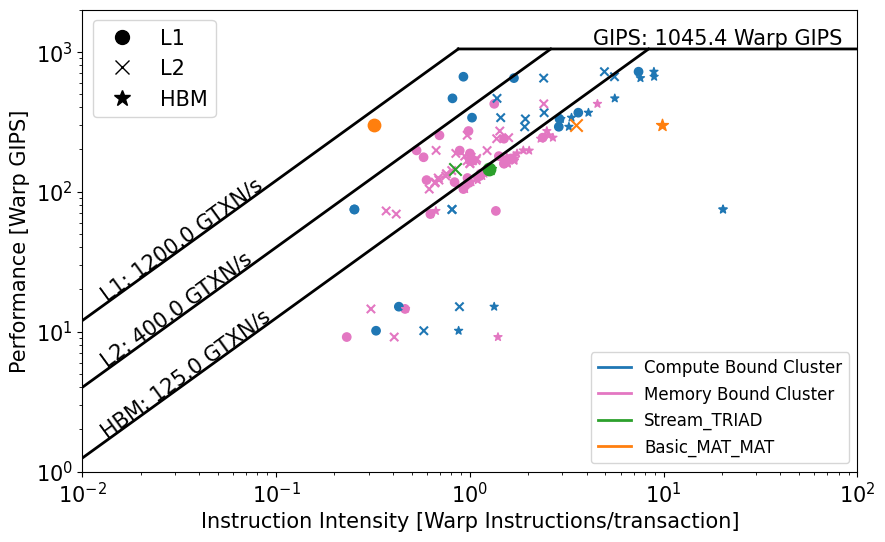

In [17]:
roofline(LABELS=pruned_th.dataframe["name"].tolist(), flag="all", data_df=agg_df, final_colors=final_colors)

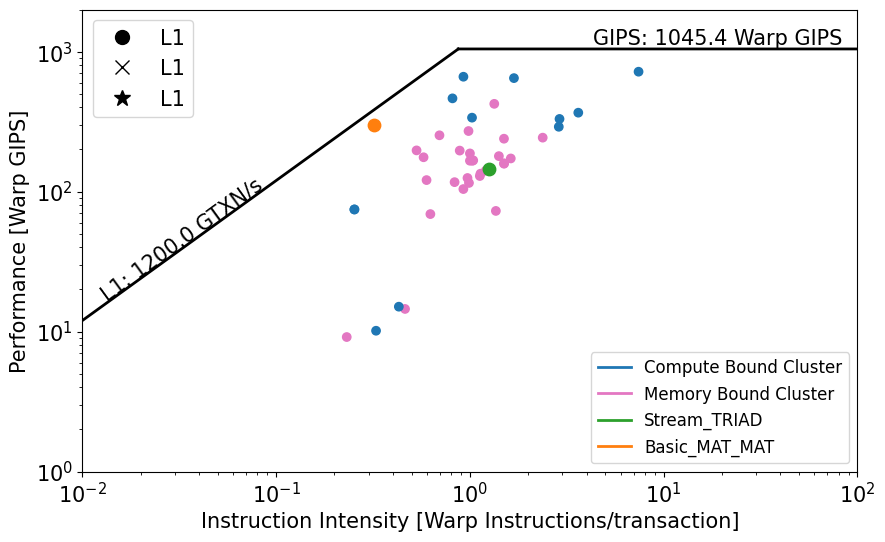

In [18]:
roofline(LABELS=pruned_th.dataframe["name"].tolist(), flag="L1", data_df=agg_df, final_colors=final_colors)

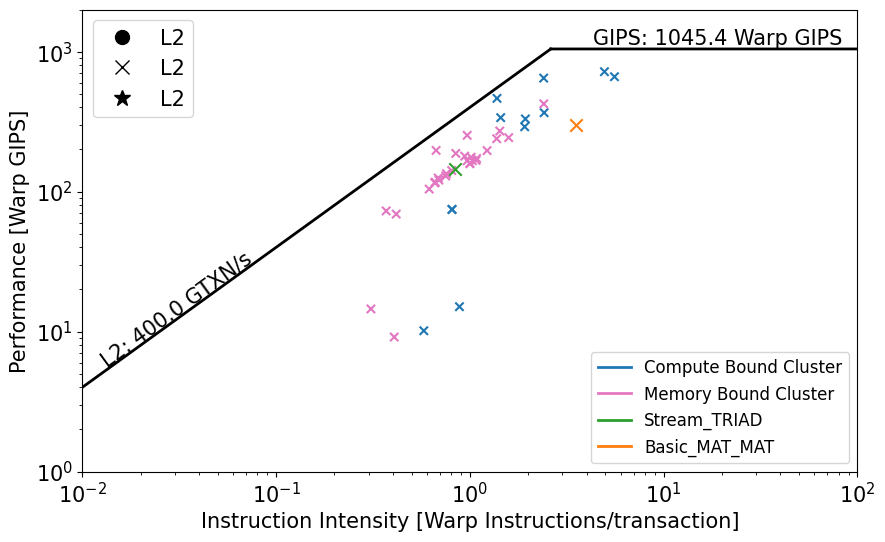

In [19]:
roofline(LABELS=pruned_th.dataframe["name"].tolist(), flag="L2", data_df=agg_df, final_colors=final_colors)

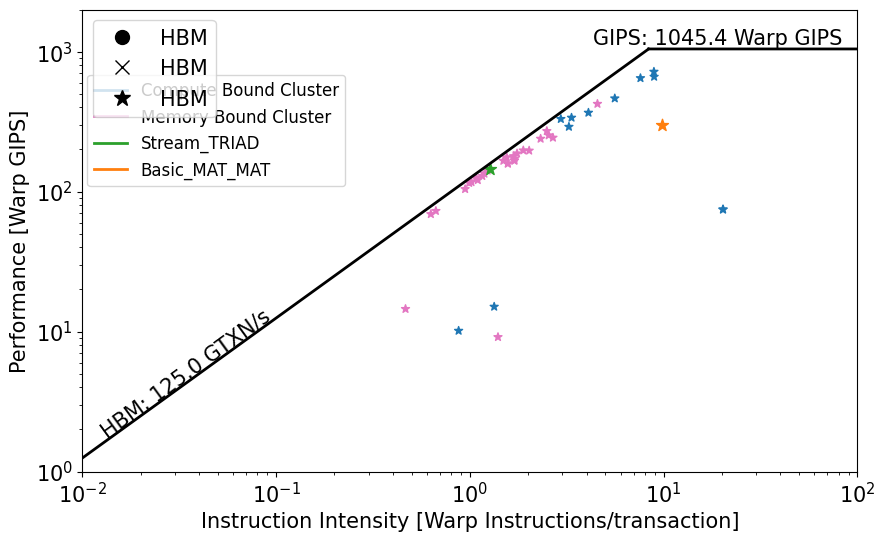

In [20]:
roofline(LABELS=pruned_th.dataframe["name"].tolist(), flag="HBM", data_df=agg_df, final_colors=final_colors)